In [1]:
import os
os.chdir('/Users/jeffreybloodworth/Desktop/git-repos/scRNAseq-ExplainableML')
os.getcwd()

'/Users/jeffreybloodworth/Desktop/git-repos/scRNAseq-ExplainableML'

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
X = pd.read_csv(
    "data/processed/ml_matrix_top2000.csv.gz",
    index_col=0
)

meta = pd.read_csv(
    "data/processed/pdc_metadata.csv"
)

In [31]:
X = X.fillna(0)


In [32]:
meta_rf = meta[
    meta["cell"].isin(X.index)
].copy()

meta_rf = (
    meta_rf
    .set_index("cell")
    .loc[X.index]
    .reset_index()
)

if "index" in meta_rf.columns:
    meta_rf = meta_rf.rename(
        columns={"index": "cell"}
    )

In [33]:
genes = [
    "ALOX5AP",
    "ALKBH7",
    "SIGLEC6",
    "HES6",
    "PDLIM1",
    "IGLL1"
]

[g for g in genes if g in X.columns]

['ALOX5AP', 'ALKBH7', 'SIGLEC6', 'HES6', 'PDLIM1', 'IGLL1']

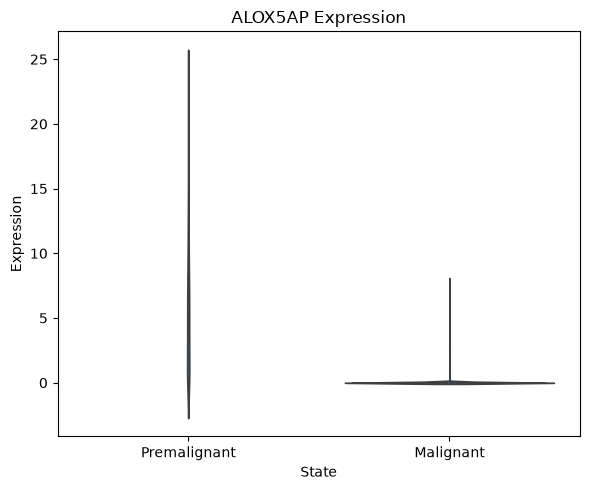

In [34]:
gene = "ALOX5AP"

df = make_gene_df(gene)

plt.figure(figsize=(6,5))

sns.violinplot(
    data=df,
    x="State",
    y="Expression",
    inner="quartile"
)

plt.title(
    f"{gene} Expression"
)

plt.tight_layout()

plt.show()

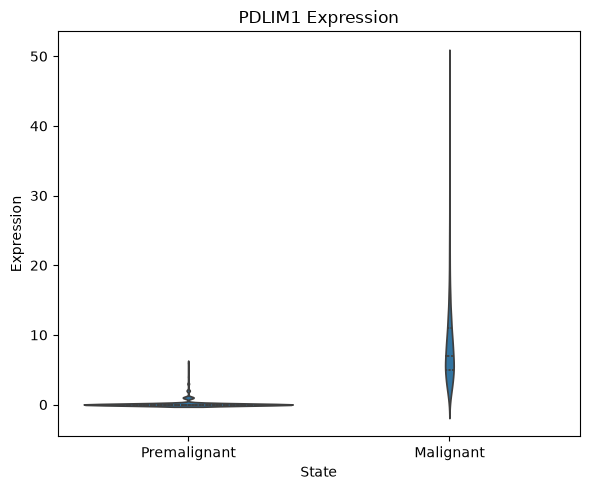

In [35]:
gene = "PDLIM1"

df = make_gene_df(gene)

plt.figure(figsize=(6,5))

sns.violinplot(
    data=df,
    x="State",
    y="Expression",
    inner="quartile"
)

plt.title(
    f"{gene} Expression"
)

plt.tight_layout()

plt.show()

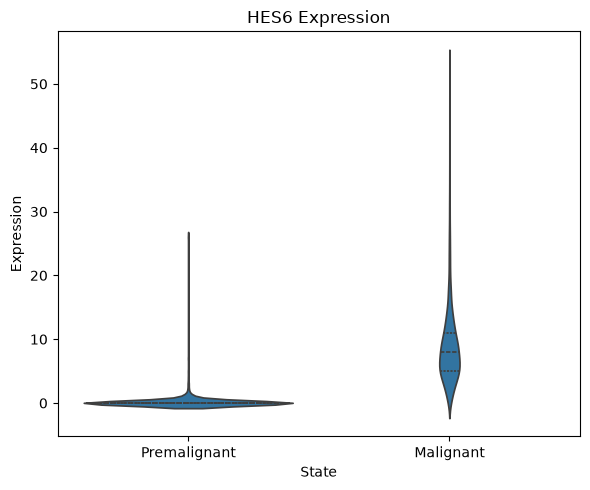

In [36]:
gene = "HES6"

df = make_gene_df(gene)

plt.figure(figsize=(6,5))

sns.violinplot(
    data=df,
    x="State",
    y="Expression",
    inner="quartile"
)

plt.title(
    f"{gene} Expression"
)

plt.tight_layout()

plt.show()

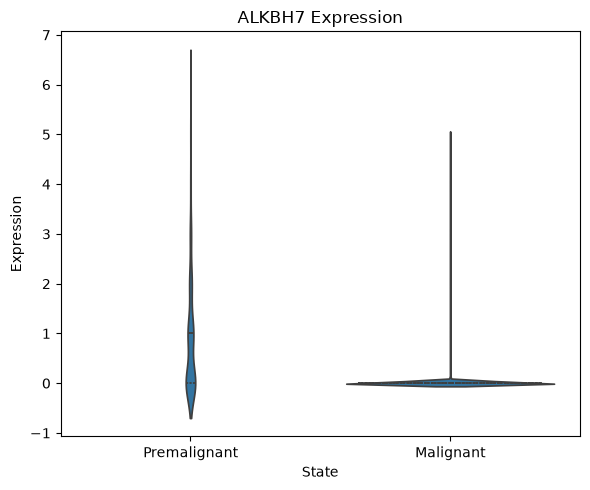

In [37]:
gene = "ALKBH7"

df = make_gene_df(gene)

plt.figure(figsize=(6,5))

sns.violinplot(
    data=df,
    x="State",
    y="Expression",
    inner="quartile"
)

plt.title(
    f"{gene} Expression"
)

plt.tight_layout()

plt.show()

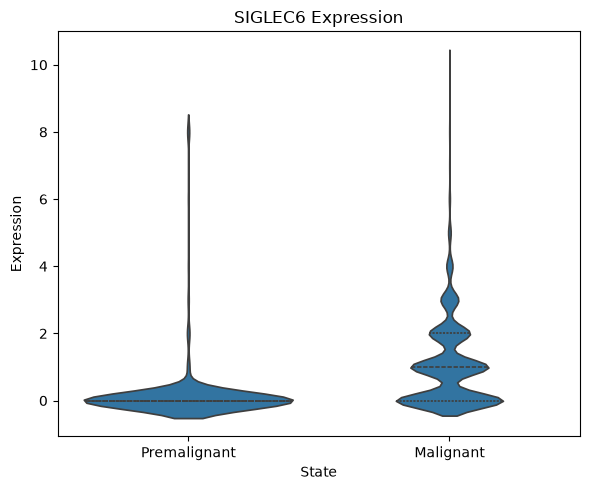

In [38]:
gene = "SIGLEC6"

df = make_gene_df(gene)

plt.figure(figsize=(6,5))

sns.violinplot(
    data=df,
    x="State",
    y="Expression",
    inner="quartile"
)

plt.title(
    f"{gene} Expression"
)

plt.tight_layout()

plt.show()

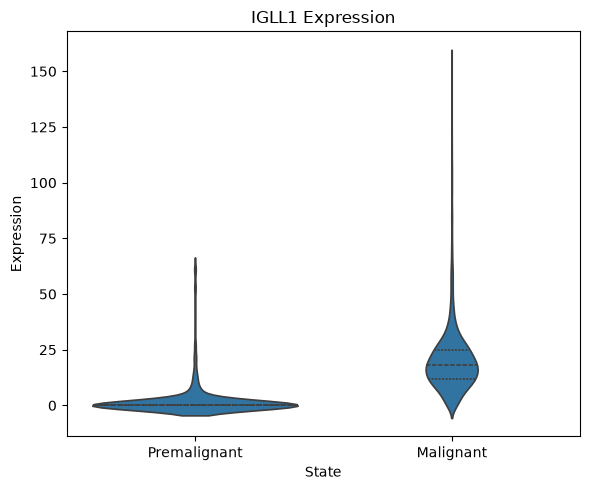

In [39]:
gene = "IGLL1"

df = make_gene_df(gene)

plt.figure(figsize=(6,5))

sns.violinplot(
    data=df,
    x="State",
    y="Expression",
    inner="quartile"
)

plt.title(
    f"{gene} Expression"
)

plt.tight_layout()

plt.show()

In [40]:
print(X.shape)

print(X.index[:5])

print(X.columns[:5])

(4846, 2000)
Index(['CACCCCCGGGCT-Pt9Dx.1', 'CGTTATCTTAGC-Pt9Dx.1', 'CTGATCGCATCG-Pt9Dx.1',
       'CGCACGCATCTG-Pt9Dx.1', 'CAGTGTCCCGGG-Pt9Dx.1'],
      dtype='str')
Index(['PTMA', 'RPLP1', 'B2M', 'RPL10', 'ACTB'], dtype='str')


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

for gene in genes:

    if gene not in X.columns:
        print(f"Skipping {gene} (not found)")
        continue

    df = pd.DataFrame({
        "Expression": X[gene].values,
        "State": meta_rf["is_malignant"].values
    })

    plt.figure(figsize=(6,5))

    sns.violinplot(
        data=df,
        x="State",
        y="Expression",
        inner="quartile"
    )

    plt.title(f"{gene} Expression")
    plt.tight_layout()

    plt.savefig(
        f"figures/{gene}_violin.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("Violin plots saved.")

Violin plots saved.


In [42]:
for gene in genes:

    if gene not in X.columns:
        continue

    df = pd.DataFrame({
        "Expression": X[gene].values,
        "State": meta_rf["is_malignant"].values
    })

    plt.figure(figsize=(6,5))

    sns.boxplot(
        data=df,
        x="State",
        y="Expression"
    )

    plt.title(f"{gene} Expression")
    plt.tight_layout()

    plt.savefig(
        f"figures/{gene}_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("Boxplots saved.")

Boxplots saved.


In [43]:
from scipy.stats import mannwhitneyu
import numpy as np

results = []

for gene in genes:

    if gene not in X.columns:
        continue

    prem = X.loc[
        (meta_rf["is_malignant"] == "Premalignant").values,
        gene
    ]

    mal = X.loc[
        (meta_rf["is_malignant"] == "Malignant").values,
        gene
    ]

    stat, p = mannwhitneyu(
        prem,
        mal,
        alternative="two-sided"
    )

    results.append({
        "Gene": gene,
        "Premalignant_Mean": prem.mean(),
        "Malignant_Mean": mal.mean(),
        "Log2FC": np.log2(
            (mal.mean() + 1e-6) /
            (prem.mean() + 1e-6)
        ),
        "Pvalue": p
    })

validation = pd.DataFrame(results)

validation.sort_values("Pvalue")

,Gene,Premalignant_Mean,Malignant_Mean,Log2FC,Pvalue
0,ALOX5AP,5.594104,0.014075,-8.634535,0.000000e+00
1,ALKBH7,0.911565,0.009535,-6.578876,0.000000e+00
4,PDLIM1,0.117914,8.177072,6.115767,8.550551e-257
3,HES6,0.172336,8.959591,5.700132,3.016249e-250
5,IGLL1,2.011338,20.503973,3.349675,7.178399e-214
2,SIGLEC6,0.142857,1.029285,2.848989,2.317781e-86


In [44]:
for gene in [
    "ALOX5AP",
    "ALKBH7",
    "SIGLEC6"
]:

    prem = X.loc[
        (meta_rf["is_malignant"]=="Premalignant").values,
        gene
    ]

    mal = X.loc[
        (meta_rf["is_malignant"]=="Malignant").values,
        gene
    ]

    print("\n", gene)

    print("Prem missing:",
          prem.isna().sum())

    print("Mal missing:",
          mal.isna().sum())


 ALOX5AP
Prem missing: 0
Mal missing: 0

 ALKBH7
Prem missing: 0
Mal missing: 0

 SIGLEC6
Prem missing: 0
Mal missing: 0


In [45]:
X[["ALOX5AP", "ALKBH7", "SIGLEC6"]].isna().sum()

ALOX5AP    0
ALKBH7     0
SIGLEC6    0
dtype: int64

In [46]:
tmp = pd.DataFrame({
    "sample": meta_rf["sample"],
    "ALOX5AP": X["ALOX5AP"]
})

tmp.groupby("sample")["ALOX5AP"].apply(
    lambda x: x.isna().sum()
)

sample
GSE227690_Pt10Dx       59
GSE227690_Pt10Rel    4382
GSE227690_Pt12Dx      267
GSE227690_Pt9Dx       138
Name: ALOX5AP, dtype: int64

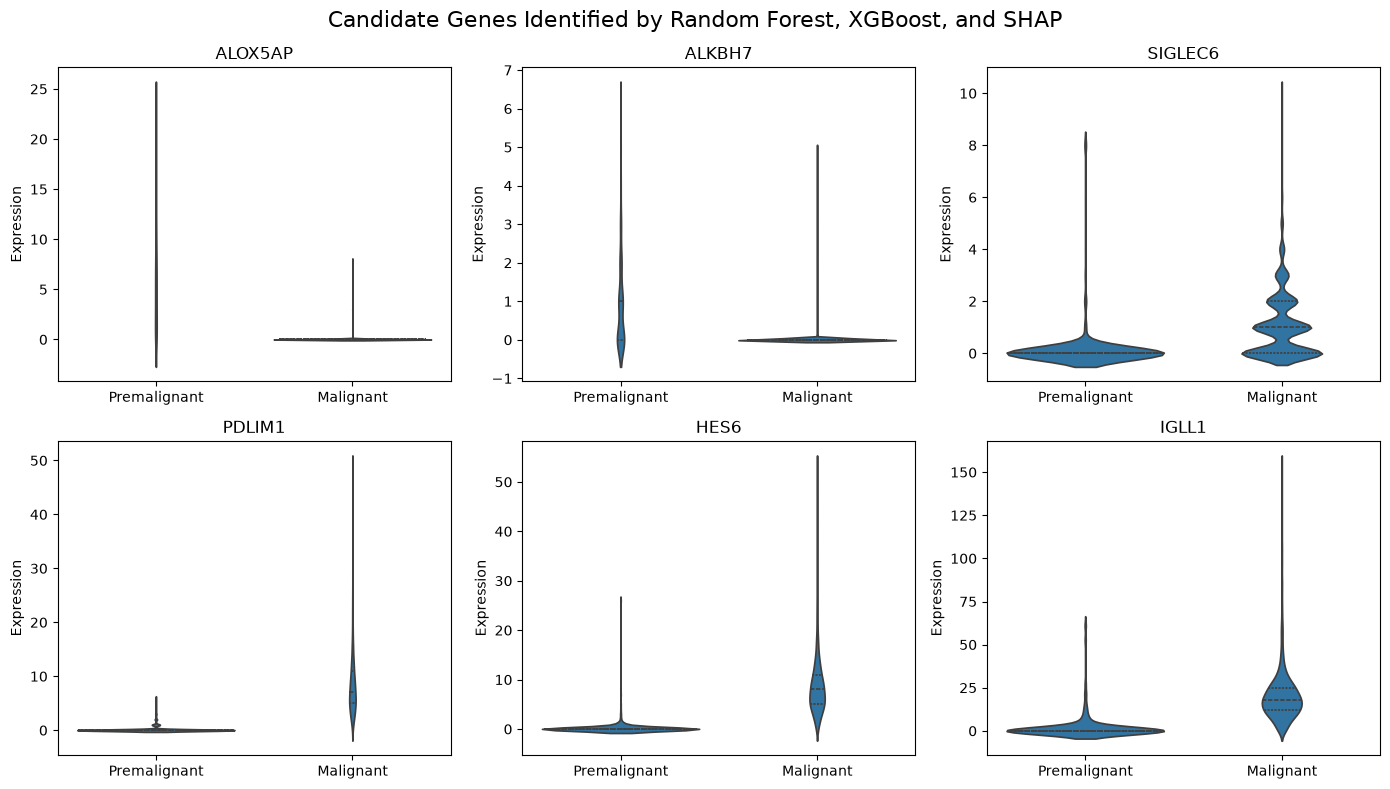

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

genes = [
    "ALOX5AP",
    "ALKBH7",
    "SIGLEC6",
    "PDLIM1",
    "HES6",
    "IGLL1"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8)
)

axes = axes.flatten()

for ax, gene in zip(axes, genes):

    if gene not in X.columns:
        ax.set_visible(False)
        continue

    df = pd.DataFrame({
        "Expression": X[gene].values,
        "State": meta_rf["is_malignant"].values
    })

    sns.violinplot(
        data=df,
        x="State",
        y="Expression",
        inner="quartile",
        ax=ax
    )

    ax.set_title(gene)
    ax.set_xlabel("")
    ax.set_ylabel("Expression")

plt.suptitle(
    "Candidate Genes Identified by Random Forest, XGBoost, and SHAP",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "figures/candidate_gene_validation_panel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
validation.to_csv(
    "results/candidate_gene_validation.csv",
    index=False
)

print(validation)

      Gene  Premalignant_Mean  Malignant_Mean    Log2FC         Pvalue
0  ALOX5AP           5.594104        0.014075 -8.634535   0.000000e+00
1   ALKBH7           0.911565        0.009535 -6.578876   0.000000e+00
2  SIGLEC6           0.142857        1.029285  2.848989   2.317781e-86
3     HES6           0.172336        8.959591  5.700132  3.016249e-250
4   PDLIM1           0.117914        8.177072  6.115767  8.550551e-257
5    IGLL1           2.011338       20.503973  3.349675  7.178399e-214


In [49]:
validation = validation.sort_values(
    "Pvalue"
)

validation.to_csv(
    "results/candidate_gene_validation.csv",
    index=False
)